In [1]:
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import numpy as np # linear algebra
import scipy as sp
from scipy import stats
from scipy.stats import zscore
import scipy.cluster.hierarchy as sch
from itertools import combinations  # added for phase 2 deduplication
import regex
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer

In [2]:
# Set pandas display options to ensure all columns are displayed in a single line
pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.width', 1000)  # Set a large width to avoid line breaks

***************************************************
# Milestone 1: Project Data Preparation and Exploratory Analysis
***************************************************

Sections
1. Introduction

   1.1 Project Overview

   1.2 Dataset Overview
   
2. Data Cleaning

   2.1 Handling Missing Data

   2.2 Outlier Detection and Treatment

   2.3 Scaling and Normalization
    
3. Feature Engineering

   3.1 New Features Created

   3.2 Transformation of Categorical Features
    
4. Exploratory Data Analysis

   4.1 Overview of the EDA Approach

   4.2 Descriptive Statistics and Visualization
    
5. Key Patterns and Insights

   5.1 Identified Patterns

   5.2 Feature Importance
    

# 1. Introduction

#   1.1 Project Overview
    
    FinMark Corporation currently offers financial products such as savings accounts, credit cards, and loans with a one-size-fits-all approach. However, customer needs and financial behaviors vary significantly, making generic product offerings ineffective. This lack of personalization may lead to customer churn, reduced engagement, and inefficient marketing efforts. Many customers may feel that the financial products available to them do not align with their specific financial situations or goals, prompting them to explore alternative options from competitors.

    To address these possible challenges, FinMark aims to implement customer segmentation using clustering techniques. By analyzing customer transaction behavior, product preferences, and feedback, the company can create meaningful customer groups. These segments will allow FinMark to:

        Recommend personalized financial products that better match customer needs.
    
        Improve customer satisfaction and retention by providing relevant offers.
    
        Optimize marketing strategies to target the right customer segments effectively.

#   1.2 Dataset Overview

    Three datasets are used in this analysis:
    
    1.2.1 Customer Feedback Data - Dataset captures customer feedback in the following areas: satisfaction score, feedback comment, and likelihood to recommend. It has 4 columns and 5050 records. There's no Feedback_ID that serves as a unique identifier. It will help if the company can at least include a date from which feedback was received to help in ensuring all feedback records analyzed are unique. I'll be working under the assumption that each record is unique after exact duplicates are removed. Its key features are Satisfaction Score, Likelihood to Recommend. This will aid the segmentation process by providing insights into customer sentiment and loyalty.

        Customer_ID (int) - Unique identifier for each customer.
        Satisfaction_Score (float, contains missing values, has very high values) - metric that measures how satisfied a customer is with a company's products or services.
        Feedback_Comments (object) - Customer feedback categorized (Very satisfied, Needs improvement, Unsatisfactory, Good service, and Excellent)
        Likelihood_to_Recommend (int) - metric that measures how likely a customer is to recommend a product, service, or company to others (Range 1-10)
    
    1.2.2 Product Offering Data - Dataset lists financial products offered by FinMark. It has 6 columns and 15 records. Product_ID is the unique identifier. The key features are: Product Type, Risk Level, Target Income Group. This will be very helpful in matching customer segments with suitable products.

        Product_ID (int) – Unique product identifier.
        Product_Name (object) – Name of the financial product.
        Product_Type (object) – Category of the product (e.g., Loan, Investment, Credit Card).
        Risk_Level (object) – Risk associated with the product (Low, Medium, High).
        Target_Age_Group (float, completely missing values) – Age group intended for the product.
        Target_Income_Group (object) – Income level the product is designed for.
    
    1.2.3 Transactions Data - Dataset contains records of customer transactions. It has 5 columns and 5050 records. Transaction_ID is the unique identifier. The key features are: Transaction Type, Transaction Amount, and Transaction Date. This dataset will be impactful in the segmentation process as it will be used in identifying spending habits and financial activity levels of the customers.

        Transaction_ID (int) – Unique identifier for each transaction.
        Customer_ID (int) – Unique identifier for each customer.
        Transaction_Date (object) – Date and time of the transaction.
        Transaction_Amount (float, contains missing values) – Amount spent or invested.
        Transaction_Type (object) – Type of transaction (e.g., Purchase, Bill Payment, Investment).

    The following are the three customer personas that I am suggesting per initial analysis of the three datasets:

        1. High-Spending Investors – Customers who frequently invest in high-risk products and have high transaction volumes.
    
        2. Budget-Conscious Savers – Customers who primarily use savings accounts and engage in low-risk financial behavior.
    
        3. Frequent Borrowers – Customers who rely on loans and credit cards for financial flexibility.

    These segments will enable targeted financial product recommendations that align with customer needs, improving engagement and product adoption. But changes are expected to be made once Feature Engineering and EDA processes are completed.

In [3]:
# Load the datasets
data1 = pd.read_csv('/Users/fritzcabalhin/Desktop/3. Data Mining Principles/FinMark Corp Raw Datasets/Customer_Feedback_Data.csv')
data2 = pd.read_csv('/Users/fritzcabalhin/Desktop/3. Data Mining Principles/FinMark Corp Raw Datasets/Product_Offering_Data.csv')
data3 = pd.read_csv('/Users/fritzcabalhin/Desktop/3. Data Mining Principles/FinMark Corp Raw Datasets/Transaction_Data.csv')

# Define datasets and dataset_names
datasets = [data1, data2, data3] #replace
dataset_names = ['customer_feedback_data','product_offering_data','transaction_data']
dataset_titles = ['Customer Feedback','Product Offering','Transactions']

# Preprocessing: Identifying shape of the dataset and data types of each columns

In [4]:
print("*************************************************************")
print("Milestone 1: Project Exploratory Data Analysis Report (Draft)") #replace
print("*************************************************************")

# Check for number of columns and rows for each dataset
print("\nPrior to preprocessing:")
for df, dataset_name in zip(datasets, dataset_names):
    print(f"\n{dataset_name} has {df.shape[1]} columns and {df.shape[0]} rows.")
    # Check for data types
    print(f"Data types for each column:\n{df.dtypes}")

*************************************************************
Milestone 1: Project Exploratory Data Analysis Report (Draft)
*************************************************************

Prior to preprocessing:

customer_feedback_data has 4 columns and 5050 rows.
Data types for each column:
Customer_ID                  int64
Satisfaction_Score         float64
Feedback_Comments           object
Likelihood_to_Recommend      int64
dtype: object

product_offering_data has 6 columns and 15 rows.
Data types for each column:
Product_ID               int64
Product_Name            object
Product_Type            object
Risk_Level              object
Target_Age_Group       float64
Target_Income_Group     object
dtype: object

transaction_data has 5 columns and 5050 rows.
Data types for each column:
Transaction_ID          int64
Customer_ID             int64
Transaction_Date       object
Transaction_Amount    float64
Transaction_Type       object
dtype: object


# Check for duplicate rows and remove them

In [5]:
def deduplication_phase1(datasets, dataset_names, dataset_titles):
    """
    Performs the first phase of deduplication on multiple datasets.
    
    Parameters:
    datasets (list of pd.DataFrame): List of dataframes to deduplicate.
    dataset_names (list of str): List of dataset names corresponding to the dataframes.
    dataset_titles (list of str): List of dataset titles for printing in the output.
    
    Returns:
    dict: A dictionary where the keys are cleaned dataset names and the values are the cleaned dataframes.
    """
    deduplicated_datasets_phase1 = {}

    for df, dataset_name, dataset_title in zip(datasets, dataset_names, dataset_titles):
        
        # Check for duplicates
        duplicates_phase1 = df.duplicated()  # This returns a boolean Series    
        
        # Count the number of duplicate rows
        num_duplicates_phase1 = duplicates_phase1.sum()  # Sum of True values gives the count
        
        # Print the number of duplicate rows
        if num_duplicates_phase1 > 0:
            print("\n------------------------------------------------------------------")
            print(f"--- First Phase of Deduplication for {dataset_title} ---")
            print("------------------------------------------------------------------")
            print(f"Findings: {dataset_title} has {num_duplicates_phase1} duplicate rows.")
        else:
            print(f"Findings: {dataset_title} has no duplicate rows.")
        
        # Remove duplicates and keep the first occurrence
        df_deduplication_phase1 = df.drop_duplicates(keep='first')
        
        # Print the number of duplicates removed
        num_removed_phase1 = len(df) - len(df_deduplication_phase1)
        print(f"Action/s: Removed {num_removed_phase1} duplicate rows from {dataset_title}.")
        
        # Print the number of rows after removal
        print(f"Results: {dataset_title} now has {len(df_deduplication_phase1)} rows after the first phase of deduplication.")
        
        # Save cleaned dataset with modified name
        deduplicated_dataset_name = dataset_name + "_deduplication_phase1"
        deduplicated_datasets_phase1[deduplicated_dataset_name] = df_deduplication_phase1
        
        # Save cleaned dataset to CSV
        df_deduplication_phase1.to_csv(f"{deduplicated_dataset_name}.csv", index=False)
        print(f"Cleaned dataset saved as {deduplicated_dataset_name}.csv")

    return deduplicated_datasets_phase1

# Call deduplication_phase1 for all datasets
deduplicated_datasets_phase1 = deduplication_phase1(datasets, dataset_names, dataset_titles)


------------------------------------------------------------------
--- First Phase of Deduplication for Customer Feedback ---
------------------------------------------------------------------
Findings: Customer Feedback has 81 duplicate rows.
Action/s: Removed 81 duplicate rows from Customer Feedback.
Results: Customer Feedback now has 4969 rows after the first phase of deduplication.
Cleaned dataset saved as customer_feedback_data_deduplication_phase1.csv

------------------------------------------------------------------
--- First Phase of Deduplication for Product Offering ---
------------------------------------------------------------------
Findings: Product Offering has 5 duplicate rows.
Action/s: Removed 5 duplicate rows from Product Offering.
Results: Product Offering now has 10 rows after the first phase of deduplication.
Cleaned dataset saved as product_offering_data_deduplication_phase1.csv

------------------------------------------------------------------
--- First Phase

In [6]:
# Load the datasets
data1 = pd.read_csv('/Users/fritzcabalhin/Desktop/3. Data Mining Principles/customer_feedback_data_deduplication_phase1.csv')
data2 = pd.read_csv('/Users/fritzcabalhin/Desktop/3. Data Mining Principles/product_offering_data_deduplication_phase1.csv')
data3 = pd.read_csv('/Users/fritzcabalhin/Desktop/3. Data Mining Principles/transaction_data_deduplication_phase1.csv')

# Define datasets and dataset_names
datasets = [data1, data2, data3] #replace
dataset_names = ['customer_feedback_data','product_offering_data','transaction_data']
dataset_titles = ['Customer Feedback','Product Offering','Transactions']

for df, dataset_title in zip(datasets, dataset_titles):
    print(f"\n {dataset_title} statistics for numerical and categorical columns: \n{df.describe(include='all')}")


 Customer Feedback statistics for numerical and categorical columns: 
        Customer_ID  Satisfaction_Score Feedback_Comments  Likelihood_to_Recommend
count   4969.000000         4869.000000              4969              4969.000000
unique          NaN                 NaN                 5                      NaN
top             NaN                 NaN      Good service                      NaN
freq            NaN                 NaN              1489                      NaN
mean     501.988126            5.693161               NaN                 5.569732
std      288.781086            3.616859               NaN                 2.867726
min        1.000000            1.000000               NaN                 1.000000
25%      254.000000            3.000000               NaN                 3.000000
50%      502.000000            6.000000               NaN                 6.000000
75%      752.000000            8.000000               NaN                 8.000000
max     1000.000

# Display unique values per column

In [7]:
# Function to display unique values per column for a dataset
def display_unique_values(datasets, dataset_names):
    """
    Displays the unique values in each column of the given datasets.
    
    Parameters:
    datasets (list of pd.DataFrame): List of datasets to inspect.
    dataset_names (list of str): List of dataset names corresponding to the dataframes.
    
    Returns:
    None
    """
    for df, dataset_title in zip(datasets, dataset_titles):
        print('**********************************************************')
        print(f"--- Unique Values in columns for {dataset_title} ---")
        print('**********************************************************')
        for column in df.columns:
            unique_values = df[column].unique()
            print(f"Column: {column}")
            print(f"Unique Values ({len(unique_values)}): {unique_values}")
            print(' ' * 50)

# Call the function to display unique values
display_unique_values(datasets, dataset_names)

**********************************************************
--- Unique Values in columns for Customer Feedback ---
**********************************************************
Column: Customer_ID
Unique Values (1000): [   1    2    3    4    5    6    7    8    9   10   11   12   13   14
   15   16   17   18   19   20   21   22   23   24   25   26   27   28
   29   30   31   32   33   34   35   36   37   38   39   40   41   42
   43   44   45   46   47   48   49   50   51   52   53   54   55   56
   57   58   59   60   61   62   63   64   65   66   67   68   69   70
   71   72   73   74   75   76   77   78   79   80   81   82   83   84
   85   86   87   88   89   90   91   92   93   94   95   96   97   98
   99  100  101  102  103  104  105  106  107  108  109  110  111  112
  113  114  115  116  117  118  119  120  121  122  123  124  125  126
  127  128  129  130  131  132  133  134  135  136  137  138  139  140
  141  142  143  144  145  146  147  148  149  150  151  152  153  154
  15

# 2. Data Cleaning

#   2.1 Handling Missing Data

    2.1.1 Transaction Data: Transaction_Amount has 100 missing values. Missing values will be deleted altogether since missingness rate of Satisfaction_Score is pretty low (2.01%).
    
    2.1.2 Product Offering Data: Target_Age_Group is entirely missing (100% missingness rate) and will be excluded from analysis.
    
    2.1.3 Customer Feedback Data: Satisfaction_Score has 100 missing values, which will be deleted altogether since missingness rate of Transaction_Amount is low (2.0%).

# Identifying columns with null values

In [8]:
# Function to check for missing values and print only columns with missing values
def check_missing_values(datasets, dataset_titles):
    """
    Checks for missing values in the datasets and prints the variables with missing values.

    Parameters:
    datasets (list of pd.DataFrame): List of dataframes to check.
    dataset_names (list of str): List of dataset names corresponding to the dataframes.
    """
    for df, dataset_title in zip(datasets, dataset_titles):
        # print(f"\nMissing values for {dataset_name}:")
        missing_values = df.isnull().sum()  # Count missing values in each column
        missing_values = missing_values[missing_values > 0]  # Filter only those with missing values
        
        if not missing_values.empty:
            print(f"\nVariables with missing values in {dataset_title}:")
            for column, count in missing_values.items():
                print(f"{column}: {count} missing values")
        else:
            print(f"\nNo missing values found in {dataset_title}.")
            
# Call the function to check for and print columns with missing values
check_missing_values(datasets, dataset_titles)


Variables with missing values in Customer Feedback:
Satisfaction_Score: 100 missing values

Variables with missing values in Product Offering:
Target_Age_Group: 10 missing values

Variables with missing values in Transactions:
Transaction_Amount: 100 missing values


# Calculating missingness rate per column

In [9]:
# Calculate missingness for each column
def missingness_rate(datasets, dataset_titles):
    for df, dataset_title in zip(datasets, dataset_titles):
        missingness = df.isnull().sum() / len(df) * 100
        # Display missingness percentage for each column
        print(f"\nMissingness rate per column in {dataset_title}:\n{missingness}")

missingness_rate(datasets, dataset_titles)


Missingness rate per column in Customer Feedback:
Customer_ID                0.000000
Satisfaction_Score         2.012477
Feedback_Comments          0.000000
Likelihood_to_Recommend    0.000000
dtype: float64

Missingness rate per column in Product Offering:
Product_ID               0.0
Product_Name             0.0
Product_Type             0.0
Risk_Level               0.0
Target_Age_Group       100.0
Target_Income_Group      0.0
dtype: float64

Missingness rate per column in Transactions:
Transaction_ID        0.0
Customer_ID           0.0
Transaction_Date      0.0
Transaction_Amount    2.0
Transaction_Type      0.0
dtype: float64


# Deleting records with missing values

In [10]:
# Load the datasets
data1 = pd.read_csv('/Users/fritzcabalhin/Desktop/3. Data Mining Principles/customer_feedback_data_deduplication_phase1.csv')
data2 = pd.read_csv('/Users/fritzcabalhin/Desktop/3. Data Mining Principles/product_offering_data_deduplication_phase1.csv')
data3 = pd.read_csv('/Users/fritzcabalhin/Desktop/3. Data Mining Principles/transaction_data_deduplication_phase1.csv')

# Define datasets and dataset names
datasets = [data1, data2, data3]
dataset_names = ['customer_feedback_data', 'product_offering_data', 'transaction_data']
dataset_titles = ['Customer Feedback', 'Product Offering', 'Transactions']

# Clean data2 by dropping the 'Target_Age_Group' column
cleaned_data2 = data2.drop(columns=['Target_Age_Group'])

# Clean data1 and data3 by dropping rows with missing values
cleaned_data1 = data1.dropna()  # Drop rows with any missing values
cleaned_data3 = data3.dropna()  # Drop rows with any missing values

# Verify if the columns are removed by showing the first 10 rows
print(f"{dataset_titles[0]} (first 10 rows):")
print(cleaned_data1.head(10))

print(f"\n{dataset_titles[1]} (first 10 rows):")
print(cleaned_data2.head(10))

print(f"\n{dataset_titles[2]} (first 10 rows):")
print(cleaned_data3.head(10))

# Save the cleaned datasets to new CSV files
cleaned_filename_data1 = f'/Users/fritzcabalhin/Desktop/3. Data Mining Principles/{dataset_names[0]}_deleted_missing_records.csv'
cleaned_filename_data2 = f'/Users/fritzcabalhin/Desktop/3. Data Mining Principles/{dataset_names[1]}_deleted_missing_records.csv'
cleaned_filename_data3 = f'/Users/fritzcabalhin/Desktop/3. Data Mining Principles/{dataset_names[2]}_deleted_missing_records.csv'

cleaned_data1.to_csv(cleaned_filename_data1, index=False)
cleaned_data2.to_csv(cleaned_filename_data2, index=False)
cleaned_data3.to_csv(cleaned_filename_data3, index=False)

# Confirm that the files are saved
print(f"\nCleaned datasets saved to:")
print(f"Data1: {cleaned_filename_data1}")
print(f"Data2: {cleaned_filename_data2}")
print(f"Data3: {cleaned_filename_data3}")

Customer Feedback (first 10 rows):
   Customer_ID  Satisfaction_Score  Feedback_Comments  Likelihood_to_Recommend
0            1                10.0     Very satisfied                        9
1            2                 3.0     Very satisfied                        3
2            3                10.0     Very satisfied                        1
3            4                 7.0  Needs improvement                        4
4            5                 8.0     Unsatisfactory                        7
5            6                 3.0  Needs improvement                        1
6            7                 3.0  Needs improvement                        2
7            8                 7.0  Needs improvement                        5
8            9                10.0       Good service                        9
9           10                 7.0       Good service                        1

Product Offering (first 10 rows):
   Product_ID                   Product_Name     Product_Type

In [11]:
# Load the datasets
data1 = pd.read_csv('/Users/fritzcabalhin/Desktop/3. Data Mining Principles/customer_feedback_data_deleted_missing_records.csv')
data2 = pd.read_csv('/Users/fritzcabalhin/Desktop/3. Data Mining Principles/product_offering_data_deleted_missing_records.csv')
data3 = pd.read_csv('/Users/fritzcabalhin/Desktop/3. Data Mining Principles/transaction_data_deleted_missing_records.csv')

# Define datasets and dataset_names
datasets = [data1, data2, data3] #replace
dataset_names = ['customer_feedback_data','product_offering_data','transaction_data']
dataset_titles = ['Customer Feedback','Product Offering','Transactions']

for df, dataset_title in zip(datasets, dataset_titles):
    print(f"\n {dataset_title} statistics for numerical and categorical columns: \n{df.describe(include='all')}")


 Customer Feedback statistics for numerical and categorical columns: 
        Customer_ID  Satisfaction_Score Feedback_Comments  Likelihood_to_Recommend
count   4869.000000         4869.000000              4869              4869.000000
unique          NaN                 NaN                 5                      NaN
top             NaN                 NaN      Good service                      NaN
freq            NaN                 NaN              1454                      NaN
mean     501.005956            5.693161               NaN                 5.565825
std      288.485855            3.616859               NaN                 2.871178
min        1.000000            1.000000               NaN                 1.000000
25%      253.000000            3.000000               NaN                 3.000000
50%      499.000000            6.000000               NaN                 6.000000
75%      750.000000            8.000000               NaN                 8.000000
max     1000.000

#   2.2 Outlier Detection and Treatment   
    
    2.2.1 Satisfaction_Score has an outlier with a maximum value of 60 (expected range is 1-10); values above 10 will be treated as data entry errors and replaced with the median.

    2.2.2 Transaction_Amount has extreme values; values above the 99th percentile will be capped.

count    4869.000000
mean        5.693161
std         3.616859
min         1.000000
25%         3.000000
50%         6.000000
75%         8.000000
max        60.000000
Name: Satisfaction_Score, dtype: float64

Outliers detected using IQR method:
      Satisfaction_Score
522                 52.0
564                 60.0
840                 56.0
1065                60.0
2393                51.0
2942                58.0
3228                51.0
4023                53.0
4382                58.0
4526                54.0

Number of outliers (based on Z-score): 10
Outliers detected (based on Z-score):
      Customer_ID  Satisfaction_Score Feedback_Comments  Likelihood_to_Recommend
522           530                52.0      Good service                       10
564           574                60.0      Good service                        9
840           858                56.0    Very satisfied                       10
1065          218                60.0      Good service                   

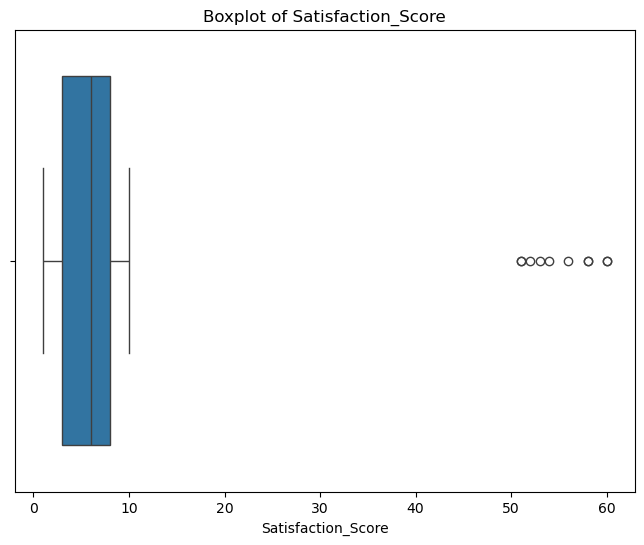

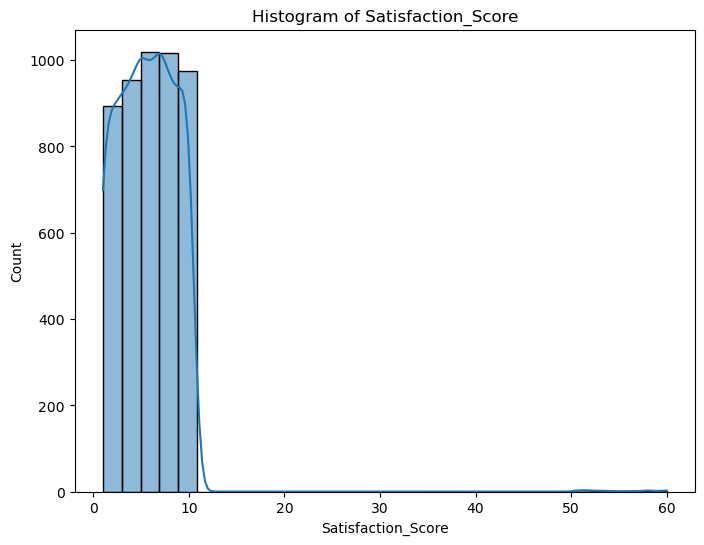

In [26]:
# 1. Descriptive Statistics: Check for the range, mean, and quartiles of the 'Satisfaction_Score'
print(data1['Satisfaction_Score'].describe())

# 2. IQR Method: Detect Outliers using IQR
Q1 = data1['Satisfaction_Score'].quantile(0.25)
Q3 = data1['Satisfaction_Score'].quantile(0.75)
IQR = Q3 - Q1
# Define the bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
# Find outliers
outliers = data1[(data1['Satisfaction_Score'] < lower_bound) | (data1['Satisfaction_Score'] > upper_bound)]
# Show outliers
print("\nOutliers detected using IQR method:")
print(outliers[['Satisfaction_Score']])

# 3. Calculate the Z-scores for Satisfaction_Score
z_scores = zscore(data1['Satisfaction_Score'])
# Find rows with Z-scores greater than 3 or less than -3
outliers_zscore = data1[abs(z_scores) > 3]
# Optionally: show how many outliers there are
print(f"\nNumber of outliers (based on Z-score): {outliers_zscore.shape[0]}")
print("Outliers detected (based on Z-score):")
print(outliers_zscore)

# 4. Boxplot visualization: Visualize outliers with a boxplot
plt.figure(figsize=(8, 6))
sns.boxplot(x=data1['Satisfaction_Score'])
plt.title('Boxplot of Satisfaction_Score')
plt.show()

# 5. Histogram: Visualize the distribution of the Satisfaction_Score
plt.figure(figsize=(8, 6))
sns.histplot(data1['Satisfaction_Score'], bins=30, kde=True)
plt.title('Histogram of Satisfaction_Score')
plt.show()

count    4869.000000
mean        5.565825
std         2.871178
min         1.000000
25%         3.000000
50%         6.000000
75%         8.000000
max        10.000000
Name: Likelihood_to_Recommend, dtype: float64

Outliers detected using IQR method:
Empty DataFrame
Columns: [Likelihood_to_Recommend]
Index: []

Number of outliers (based on Z-score): 0
Outliers detected (based on Z-score):
Empty DataFrame
Columns: [Customer_ID, Satisfaction_Score, Feedback_Comments, Likelihood_to_Recommend]
Index: []


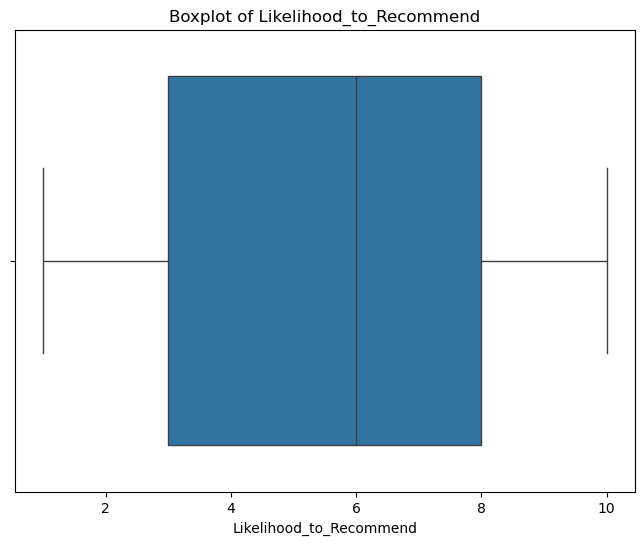

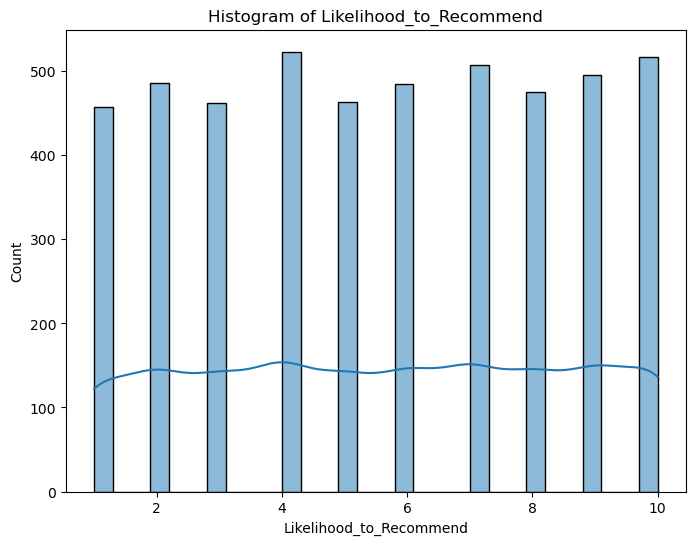

In [27]:
# 1. Descriptive Statistics: Check for the range, mean, and quartiles of the 'Likelihood_to_Recommend'
print(data1['Likelihood_to_Recommend'].describe())

# 2. IQR Method: Detect Outliers using IQR
Q1 = data1['Likelihood_to_Recommend'].quantile(0.25)
Q3 = data1['Likelihood_to_Recommend'].quantile(0.75)
IQR = Q3 - Q1
# Define the bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
# Find outliers
outliers = data1[(data1['Likelihood_to_Recommend'] < lower_bound) | (data1['Likelihood_to_Recommend'] > upper_bound)]
# Show outliers
print("\nOutliers detected using IQR method:")
print(outliers[['Likelihood_to_Recommend']])


# 3. Calculate the Z-scores for Likelihood_to_Recommend
z_scores = zscore(data1['Likelihood_to_Recommend'])
# Find rows with Z-scores greater than 3 or less than -3
outliers_zscore = data1[abs(z_scores) > 3]
# Optionally: show how many outliers there are
print(f"\nNumber of outliers (based on Z-score): {outliers_zscore.shape[0]}")
print("Outliers detected (based on Z-score):")
print(outliers_zscore)

# 4. Boxplot visualization: Visualize outliers with a boxplot
plt.figure(figsize=(8, 6))
sns.boxplot(x=data1['Likelihood_to_Recommend'])
plt.title('Boxplot of Likelihood_to_Recommend')
plt.show()

# 5. Histogram: Visualize the distribution of the Likelihood_to_Recommend
plt.figure(figsize=(8, 6))
sns.histplot(data1['Likelihood_to_Recommend'], bins=30, kde=True)
plt.title('Histogram of Likelihood_to_Recommend')
plt.show()

count      4900.000000
mean       3102.050816
std       14893.172210
min          10.000000
25%        1242.750000
50%        2481.500000
75%        3709.750000
max      480300.000000
Name: Transaction_Amount, dtype: float64

Outliers detected using IQR method:
      Transaction_Amount
597             480300.0
1236            390200.0
1702            194500.0
2001            183500.0
2140             94500.0
2226            428900.0
2974            458600.0
2995            270900.0
3216            175600.0
4755            362700.0

Number of outliers (based on Z-score): 10
Outliers detected (based on Z-score):
      Transaction_ID  Customer_ID     Transaction_Date  Transaction_Amount Transaction_Type
597              613          191  2023-01-26 12:00:00            480300.0     Bill Payment
1236            1265          772  2023-02-22 16:00:00            390200.0     Bill Payment
1702            1739           27  2023-03-14 10:00:00            194500.0     Bill Payment
2001          

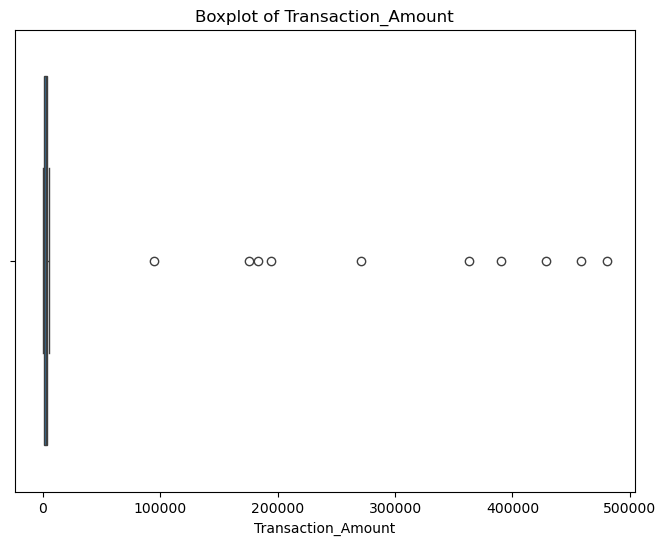

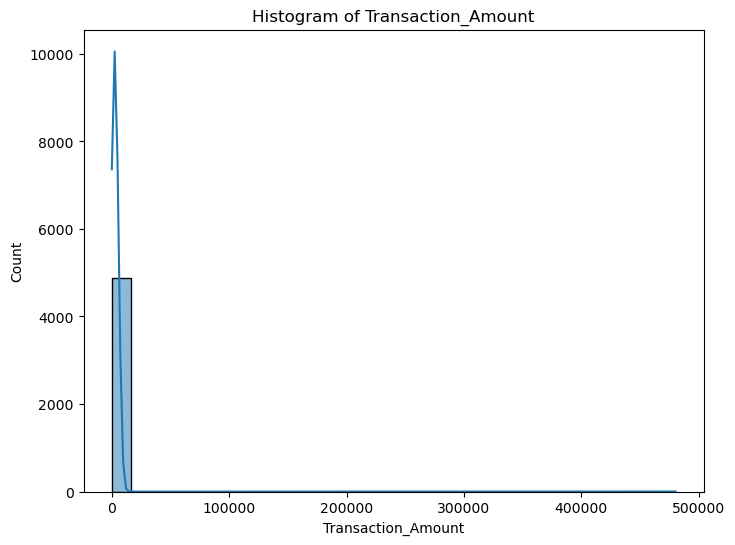

In [28]:
# 1. Descriptive Statistics: Check for the range, mean, and quartiles of the 'Transaction_Amount'
print(data3['Transaction_Amount'].describe())

# 2. IQR Method: Detect Outliers using IQR
Q1 = data3['Transaction_Amount'].quantile(0.25)
Q3 = data3['Transaction_Amount'].quantile(0.75)
IQR = Q3 - Q1
# Define the bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
# Find outliers
outliers = data3[(data3['Transaction_Amount'] < lower_bound) | (data3['Transaction_Amount'] > upper_bound)]
# Show outliers
print("\nOutliers detected using IQR method:")
print(outliers[['Transaction_Amount']])

# 3. Calculate the Z-scores for Transaction_Amount
z_scores = zscore(data3['Transaction_Amount'])
# Find rows with Z-scores greater than 3 or less than -3
outliers_zscore = data3[abs(z_scores) > 3]
# Optionally: show how many outliers there are
print(f"\nNumber of outliers (based on Z-score): {outliers_zscore.shape[0]}")
print("Outliers detected (based on Z-score):")
print(outliers_zscore)

# 4. Boxplot visualization: Visualize outliers with a boxplot
plt.figure(figsize=(8, 6))
sns.boxplot(x=data3['Transaction_Amount'])
plt.title('Boxplot of Transaction_Amount')
plt.show()

# 5. Histogram: Visualize the distribution of the Transaction_Amount
plt.figure(figsize=(8, 6))
sns.histplot(data3['Transaction_Amount'], bins=30, kde=True)
plt.title('Histogram of Transaction_Amount')
plt.show()

#   2.3 Scaling and Normalization

    2.3.1 Transaction Amount: Standardized using z-score normalization to handle large value variations.

    2.3.2 Satisfaction Score & Likelihood to Recommend: Min-max scaling applied to normalize values within a 0-1 range.

# 3. Feature Engineering

#   3.1 New Features Created
    
    3.1.1 Customer Lifetime Spend: Total amount spent per customer across all transactions.
    
    3.1.2 Average Transaction Amount: Mean value of a customer’s transactions.
    
    3.1.3 Customer Engagement Score: Derived from transaction frequency and feedback scores.

#   3.2 Transformation of Categorical Features
    
    3.2.1 Transaction Type & Product Type: Converted into numerical values using one-hot encoding.
    
    3.2.2 Risk Level: Encoded as ordinal values (Low = 0, Medium = 1, High = 2).

# 4. Exploratory Data Analysis
    
#   4.1 Overview of the EDA Approach
    EDA helps uncover patterns, trends, and relationships within the datasets, providing insights that guide clustering. The analysis includes:

    4.1.1 Descriptive statistics to summarize key features.

    4.1.2 Visualizations to detect patterns in customer spending and feedback.

#   4.2 Descriptive Statistics and Visualization
    4.2.1 Transaction Data:

        a. Mean transaction amount: ~$1,200

        b. Most common transaction type: Purchases

    4.2.2 Customer Feedback:

        a. Mean satisfaction score: ~5.68

        b. Higher transaction frequency correlates with higher likelihood to recommend.

    4.2.3 Key Visualizations:

        a. Histograms of transaction amounts

        b. Box plots for satisfaction scores

        c. Scatter plots analyzing spending vs. feedback

# 5. Key Patterns and Insights

#   5.1 Identified Patterns

    5.1.1 High-spending customers tend to have higher satisfaction scores and likelihood to recommend FinMark.

    5.1.2 Investment product users have a distinct transaction pattern compared to credit card users.

    5.1.3 Certain customer groups show low engagement despite frequent transactions, indicating potential dissatisfaction.

#   5.2 Feature Importance

    5.2.1 Transaction Frequency & Amount: Key indicators of customer behavior.

    5.2.2 Satisfaction Score & Likelihood to Recommend: Important for segmenting loyal vs. dissatisfied customers.

    5.2.3 Product Type Preferences: Helps in recommending relevant financial products.